# TP4 :  Low-budget  Learning

# Introduction

**Context :**

Assume we are in a context where few "gold" labeled data are available for training, say 

$$\mathcal{X}_{\text{train}} = \{(x_n,y_n)\}_{n\leq N_{\text{train}}}$$

where $N_{\text{train}}$ is small. Hence we are not in the context of classical well-organized benchmark datasets.

To make your life easier, you also get a validation set $\mathcal{X}_{\text{val}}$ representative of the test set, but you cannot use it for training. You can only use it to select the best model and hyperparameters.

A large test set $\mathcal{X}_{\text{test}}$ exists but is not accessible. We also assume that we have a limited computational budget (e.g., limited GPU access).


In this practical, we will use the `resnet10` architecture. 

# QUESTIONS

## Grading

You will need to provide 4 files : 
1. This Notebook
2. `utils.py`
3. `drawing_lora.png`
4. `cutmix.png`

Some of the code will be automatically graded so please follow the instructions carefully.

You will also need to participate in a competition on https://www.codabench.org to get your model evaluated on the hidden test set (the link to the competition will be provided on the course forum). Before submitting anything make sure to read the instructions on the competition page. The evaluation metric is the accuracy. However, *this is not a competition* as it is not necessary to get the best score to get a good grade. If you get a good score, and follow the instructions, you will get a good grade.

`utils.py` will be imported during the testing phase so please make sure:
- it does not execute any code when imported
- it does not depend on any module that is not standard (e.g., not `torch`, `torchvision`, `numpy`, etc.)


General instructions:
- Please provide clear and short answers between `<div class="alert alert-info">  <your answer>  </div>` tags (when it's not code).
- For each question that involves training a model:
    - Give the number of trained parameters.
    - You must provide the training curves (train & validation accuracy/loss vs epochs) in the notebook.
    - You must explain the choices you made (hyperparameters, etc). (A short justification is enough. For instance, "I used default hyperparameters." does not need further explanation. Or "I tried (0.1,0.01,0.001) and picked 0.01 because it gave the best validation accuracy." is enough.)
    - You must comment on the accuracy obtained.
- If you use a seed for reproducibility, please make sure it is a personal one using something like `hash("your_firstname_your_lastname")`.

<div class="alert alert-info">  Example of answer  </div>

In [1]:
import torch
from torchvision import datasets, transforms, models
import torch.nn as nn
from torchmetrics.classification import ConfusionMatrix


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [ ]:
import os

if not os.path.exists("data"):
    os.mkdir("data")
if not os.path.exists("data/TP4_images"):
    os.mkdir("data/TP4_images")
if not os.path.exists("data/TP4_images/north_dataset_test"):
    !cd data/TP4_images && wget -O north_dataset_train.zip  "https://nextcloud.lisn.upsaclay.fr/index.php/s/yzQRWE2YjmFn9WA/download/north_dataset_train.zip" && unzip north_dataset_train.zip
    !cd data/TP4_images && wget -O north_dataset_test.zip  "https://nextcloud.lisn.upsaclay.fr/index.php/s/zntidWrFdYsGMDm/download/north_dataset_test.zip" && unzip north_dataset_test.zip
dir_path = "data/TP4_images/"

In [ ]:
import os
import urllib.request
import zipfile

# os.makedirs with exist_ok=True is a cleaner way to create nested directories safely
os.makedirs("data/TP4_images", exist_ok=True)

dir_path = "data/TP4_images/"
test_dir = os.path.join(dir_path, "north_dataset_test")

train_url = "https://nextcloud.lisn.upsaclay.fr/index.php/s/yzQRWE2YjmFn9WA/download/north_dataset_train.zip"
test_url = "https://nextcloud.lisn.upsaclay.fr/index.php/s/zntidWrFdYsGMDm/download/north_dataset_test.zip"

train_zip_path = os.path.join(dir_path, "north_dataset_train.zip")
test_zip_path = os.path.join(dir_path, "north_dataset_test.zip")

# Only download and extract if the test directory doesn't exist
if not os.path.exists(test_dir):
    print("Downloading train dataset... (this might take a moment)")
    urllib.request.urlretrieve(train_url, train_zip_path)
    print("Extracting train dataset...")
    with zipfile.ZipFile(train_zip_path, 'r') as zip_ref:
        zip_ref.extractall(dir_path)
        
    print("Downloading test dataset...")
    urllib.request.urlretrieve(test_url, test_zip_path)
    print("Extracting test dataset...")
    with zipfile.ZipFile(test_zip_path, 'r') as zip_ref:
        zip_ref.extractall(dir_path)
        
    print("Download and extraction complete!")
else:
    print("Datasets already exist. Ready to go!")

In [2]:
val_dataset = datasets.ImageFolder(
    "data/TP4_images/north_dataset_test",
    transform=transforms.Compose([transforms.ToTensor()]),
)

train_dataset = datasets.ImageFolder(
    "data/TP4_images/north_dataset_sample",
    transform=transforms.Compose([transforms.ToTensor()]),
)


metric = ConfusionMatrix(task="multiclass", num_classes=2).to(device)


def model_instancier(**kwargs):
    """
    Instanciate a ResNet10 model (ResNet18 with only 1 block per layer).

    Parameters
    ----------
    **kwargs: dict
        Keyword arguments to pass to the ResNet18 constructor.

    Returns
    -------
    model: nn.Module
        The instantiated ResNet10 model.
    """
    _model = models.resnet18(**kwargs)
    for i in range(1, 5):
        setattr(_model, f"layer{i}", getattr(_model, f"layer{i}")[0])
    return _model


base_model = model_instancier()
classifier_name = "fc"


print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

Train dataset size: 42
Validation dataset size: 42


## Question 1: 
>  Create `last_layer.py` to change the last layer of the resnet model so that it fits the problem.

In [3]:
from last_layer import LastLayer

setattr(base_model, classifier_name, LastLayer())
assert (
    getattr(base_model, classifier_name).out_features == 2
)  # we could also change the last layer to have 1 output. Do it with 2 so that it matches our tests procedure during grading.

## Question 2: 
> Provide a function `precompute_features` in `utils.py` that creates a new dataset from the features precomputed by the model.

In [4]:
from torch.utils.data import DataLoader, TensorDataset
def precompute_features(
    model: nn.Module, dataset: torch.utils.data.Dataset, device: torch.device
) -> torch.utils.data.Dataset:
    """
    Create a new dataset with the features precomputed by the model.

    If the model is $f \circ g$ where $f$ is the last layer and $g$ is
    the rest of the model, it is not necessary to recompute $g(x)$ at
    each epoch as $g$ is fixed. Hence you can precompute $g(x)$ and
    create a new dataset
    $\mathcal{X}_{\text{train}}' = \{(g(x_n),y_n)\}_{n\leq N_{\text{train}}}$

    Arguments:
    ----------
    model: nn.Module
        The model used to precompute the features
    dataset: torch.utils.data.Dataset
        The dataset to precompute the features from
    device: torch.device
        The device to use for the computation

    Returns:
    --------
    torch.utils.data.Dataset
        The new dataset with the features precomputed
    """
    # 1. Set the model to evaluation mode
    model.eval()
    model = model.to(device)
    
    # 2. Temporarily replace the final layer with Identity to extract features
    original_fc = model.fc
    model.fc = nn.Identity()
    
    # 3. Use a DataLoader to process the dataset in batches efficiently
    dataloader = DataLoader(dataset, batch_size=64, shuffle=False)
    
    all_features = []
    all_labels = []
    
    # 4. Extract features without computing gradients
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            
            # Extract features: outputs shape (batch_size, 512)
            features = model(images)
            
            # Move features to CPU so we don't run out of GPU memory 
            # when storing the entire dataset
            all_features.append(features.cpu())
            all_labels.append(labels.cpu())
            
    # 5. Restore the original final layer to the model
    model.fc = original_fc
    
    # 6. Concatenate all batches into single tensors
    all_features = torch.cat(all_features, dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    
    # 7. Return a TensorDataset wrapping the precomputed data
    return TensorDataset(all_features, all_labels)

## Question 3: 
> Train the last layer of a randomly initialized resnet model.  Provide the training process in the notebook with training curve. Comment on the accuracy. 

In [5]:
import matplotlib.pyplot as plt
import torch.optim as optim
from torch.utils.data import DataLoader
def train_and_evaluate_classifier(
    train_features, 
    val_features, 
    classifier_layer, 
    device, 
    num_epochs=20, 
    batch_size=32, 
    lr=0.001
):
    """
    Trains a linear classifier on precomputed features and plots the learning curves.
    """
    # 1. Create DataLoaders
    train_loader = DataLoader(train_features, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_features, batch_size=batch_size, shuffle=False)
    
    # 2. Setup loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(classifier_layer.parameters(), lr=lr)
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    print("Starting training on ImageNet precomputed features...")
    
    # 3. Training Loop
    for epoch in range(num_epochs):
        # --- Training Phase ---
        classifier_layer.train()
        running_loss, correct, total = 0.0, 0, 0
        
        for features, labels in train_loader:
            features, labels = features.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = classifier_layer(features)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * features.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
        history['train_loss'].append(running_loss / total)
        history['train_acc'].append(correct / total)
        
        # --- Validation Phase ---
        classifier_layer.eval()
        running_loss, correct, total = 0.0, 0, 0
        
        with torch.no_grad():
            for features, labels in val_loader:
                features, labels = features.to(device), labels.to(device)
                outputs = classifier_layer(features)
                loss = criterion(outputs, labels)
                
                running_loss += loss.item() * features.size(0)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
                
        history['val_loss'].append(running_loss / total)
        history['val_acc'].append(correct / total)
        
        # Print progress every 5 epochs and on the first epoch
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:02d}/{num_epochs} - "
                  f"Train Acc: {history['train_acc'][-1]:.4f} - Val Acc: {history['val_acc'][-1]:.4f}")

    # 4. Plotting the learning curves
    plt.figure(figsize=(12, 5))

    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss', color='blue')
    plt.plot(history['val_loss'], label='Validation Loss', color='orange')
    plt.title('Loss over Epochs (Pretrained base)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Accuracy', color='blue')
    plt.plot(history['val_acc'], label='Validation Accuracy', color='orange')
    plt.title('Accuracy over Epochs (Pretrained base)')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()
    
    return history

In [6]:
from utils import precompute_features

In [7]:
base_model = model_instancier()
setattr(base_model, classifier_name, LastLayer())
base_model = base_model.to(device)

train_features_dataset = precompute_features(base_model, train_dataset, device=device)
val_features_dataset = precompute_features(base_model, val_dataset, device=device)

Starting training on ImageNet precomputed features...
Epoch 01/200 - Train Acc: 0.6905 - Val Acc: 0.5000
Epoch 05/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 10/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 15/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 20/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 25/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 30/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 35/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 40/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 45/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 50/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 55/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 60/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 65/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 70/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 75/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 80/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 85/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 90/200 - Train Acc: 0.

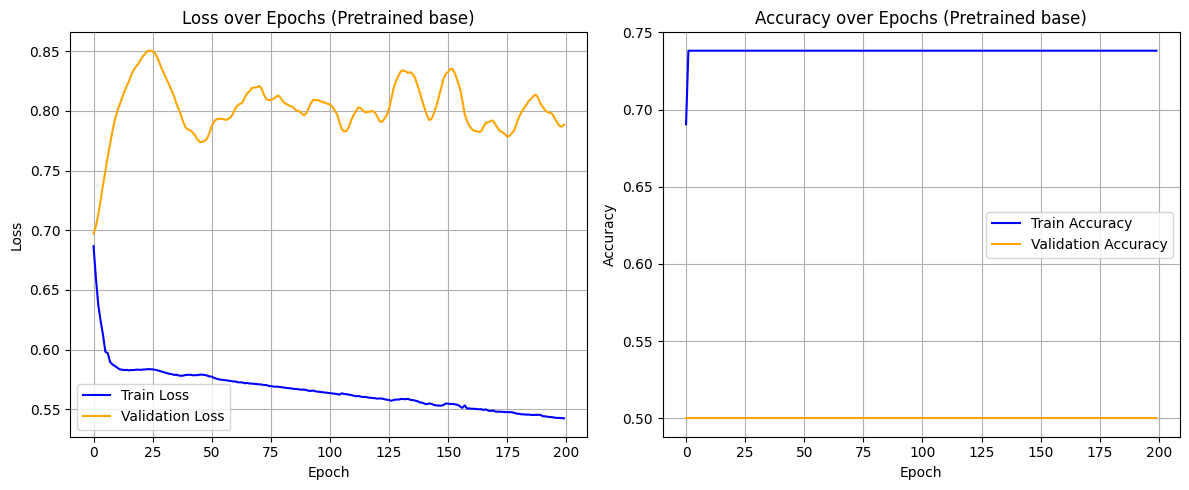

In [8]:
history = train_and_evaluate_classifier(
    train_features=train_features_dataset,
    val_features=val_features_dataset,
    classifier_layer=getattr(base_model, classifier_name),
    device=device,
    num_epochs=200,
    batch_size=32,
    lr=0.001)

1. Validation Accuracy at 50% (Random Guessing): Since this is a binary classification task (2 classes), a 50% validation accuracy means the model is performing no better than a random coin flip. This is exactly what we expect. Because the base ResNet model was randomly initialized and frozen, its convolutional layers (g(x)) are not extracting any meaningful visual features (like edges or textures). It is essentially outputting a random 512-dimensional vector for every image.

2. Training Accuracy at ~74% (Overfitting to Noise): The linear classifier (our LastLayer) is trying to find a boundary to separate the two classes based on these random 512-dimensional vectors. Because 512 dimensions give the model a lot of mathematical flexibility, it manages to memorize some random noise patterns in the training data, pushing the training accuracy to ~74%. However, because these patterns are purely random and have nothing to do with the actual images, this "knowledge" completely fails to generalize to the validation set.

Conclusion: Training only the last layer of a randomly initialized feature extractor does not work. For this approach to be effective, the base model needs to be pre-trained on a large dataset so it can provide meaningful representations to the final layer.

## Question 4:
>  Now start from a pretrained model on imagenet (https://pytorch.org/vision/stable/models.html#) and only train the last layer. Provide the training process in the notebook with training curve. 

This is the first question evaluated on the codabench platform.

In [9]:
base_model = model_instancier(weights="DEFAULT")
setattr(base_model, classifier_name, LastLayer())
base_model = base_model.to(device)

In [10]:
train_features_dataset = precompute_features(base_model, train_dataset, device=device)
val_features_dataset = precompute_features(base_model, val_dataset, device=device)

Starting training on ImageNet precomputed features...
Epoch 01/2000 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 05/2000 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 10/2000 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 15/2000 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 20/2000 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 25/2000 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 30/2000 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 35/2000 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 40/2000 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 45/2000 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 50/2000 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 55/2000 - Train Acc: 0.7381 - Val Acc: 0.5238
Epoch 60/2000 - Train Acc: 0.7381 - Val Acc: 0.5238
Epoch 65/2000 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 70/2000 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 75/2000 - Train Acc: 0.7381 - Val Acc: 0.5238
Epoch 80/2000 - Train Acc: 0.7857 - Val Acc: 0.5238
Epoch 85/2000 - Train Acc: 0.8333 - Val Acc: 0.5714
Epoch 90/2

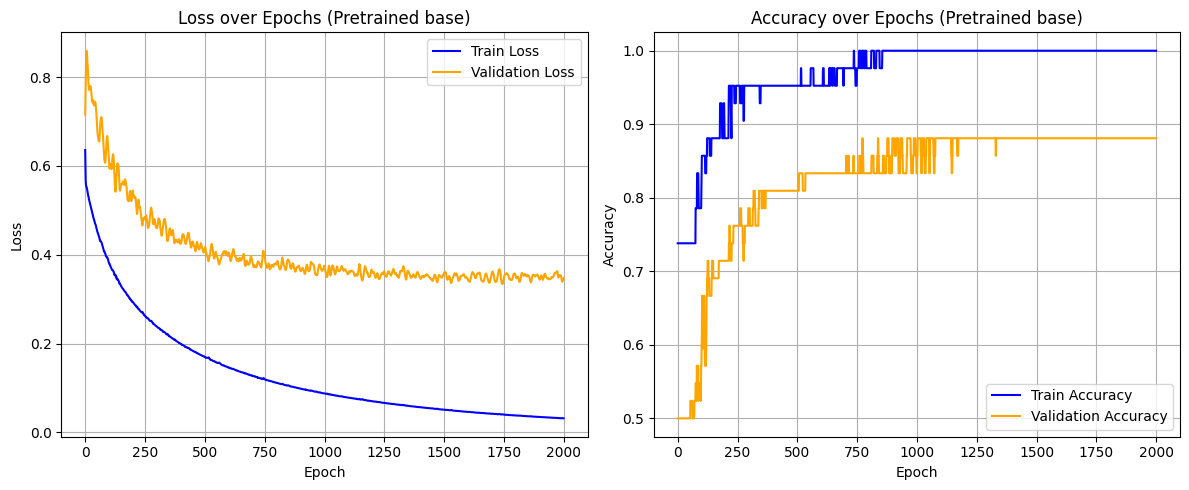

In [11]:
# Extract the classifier layer to pass into our function
classifier = getattr(base_model, classifier_name).to(device)

# Train the layer and plot the results
history = train_and_evaluate_classifier(
    train_features=train_features_dataset, 
    val_features=val_features_dataset, 
    classifier_layer=classifier, 
    device=device,
    num_epochs=2000
)

<div class="alert alert-info">  You should achieve >80% accuracy on the val set.  </div>

### Save your model

In [12]:
# Save the last layer weights for grading on codabench
torch.save(getattr(base_model, classifier_name).state_dict(), "last_layer_finetune.pth")

### Check that you can load your model

In [13]:
model = model_instancier(weights="DEFAULT")
fc = LastLayer()
fc.load_state_dict(
    torch.load("last_layer_finetune.pth", weights_only=True, map_location=device)
)
setattr(model, classifier_name, fc)
model.eval()
pass

## Question 5:
> Perform  LoRA https://arxiv.org/pdf/2106.09685  on the model  ( We are perfectly fine if you use external library for this question only ) 

Intermediate question : Describe LoRA and the difference with LoRA for Convolutions in this paper : https://arxiv.org/pdf/2401.17868  in a few lines  (you do not have to implement ConvLora)

In [ ]:
from peft import LoraConfig, get_peft_model

# 1. Start fresh with a pretrained model and your custom last layer
base_model = model_instancier(weights="DEFAULT")
setattr(base_model, classifier_name, LastLayer())

# 2. Define the LoRA Configuration
lora_config = LoraConfig(
    r=8,                  # Rank of the update matrices (lower = fewer parameters)
    lora_alpha=16,        # Scaling factor for the LoRA updates
    target_modules=["conv1", "conv2"], # Targets the Conv2d layers in ResNet blocks
    lora_dropout=0.1,     # Dropout probability for LoRA layers
    bias="none",          # Bias handling
    modules_to_save=[classifier_name] # Tells PEFT to keep our custom fc layer fully trainable!
)

# 3. Wrap the base model with the LoRA model
lora_model = get_peft_model(base_model, lora_config)
lora_model = lora_model.to(device)

# 4. Print the parameter reduction to see the advantage of LoRA
lora_model.print_trainable_parameters()

c:\Users\Yani\Documents\TP4_DLP\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


trainable params: 124,058 || all params: 5,030,876 || trainable%: 2.4659


In [15]:
def train_lora_model(
    model, 
    train_data, 
    val_data, 
    device, 
    num_epochs=10, 
    batch_size=32, 
    lr=0.001
):
    """
    Trains a PEFT/LoRA model on raw images and plots the learning curves.
    """
    # 1. Create DataLoaders using the RAW image datasets
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
    
    # 2. Setup loss and optimizer
    # Notice we pass model.parameters() because PEFT automatically handles 
    # freezing the base weights and only passing the LoRA + classifier weights to the optimizer.
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    print("Starting LoRA fine-tuning on raw images...")
    
    # 3. Training Loop
    for epoch in range(num_epochs):
        # --- Training Phase ---
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            # Forward pass now goes through the entire ResNet + LoRA layers
            outputs = model(images) 
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
        history['train_loss'].append(running_loss / total)
        history['train_acc'].append(correct / total)
        
        # --- Validation Phase ---
        model.eval()
        running_loss, correct, total = 0.0, 0, 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                running_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
                
        history['val_loss'].append(running_loss / total)
        history['val_acc'].append(correct / total)
        
        print(f"Epoch {epoch+1:02d}/{num_epochs} - "
              f"Train Acc: {history['train_acc'][-1]:.4f} - Val Acc: {history['val_acc'][-1]:.4f}")

    # 4. Plotting the learning curves
    plt.figure(figsize=(12, 5))

    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss', color='purple')
    plt.plot(history['val_loss'], label='Validation Loss', color='green')
    plt.title('Loss over Epochs (LoRA)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Accuracy', color='purple')
    plt.plot(history['val_acc'], label='Validation Accuracy', color='green')
    plt.title('Accuracy over Epochs (LoRA)')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()
    
    return history

In [16]:
# We use fewer epochs here because full-image passes take longer, 
# and LoRA usually converges quite efficiently.
lora_history = train_lora_model(
    model=lora_model, 
    train_data=train_dataset, 
    val_data=val_dataset, 
    device=device,
    num_epochs=100
)

Starting LoRA fine-tuning on raw images...
Epoch 01/100 - Train Acc: 0.6667 - Val Acc: 0.5000
Epoch 02/100 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 03/100 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 04/100 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 05/100 - Train Acc: 0.7857 - Val Acc: 0.5238
Epoch 06/100 - Train Acc: 0.8810 - Val Acc: 0.7143
Epoch 07/100 - Train Acc: 0.9048 - Val Acc: 0.7381
Epoch 08/100 - Train Acc: 0.9524 - Val Acc: 0.7381
Epoch 09/100 - Train Acc: 0.9524 - Val Acc: 0.7619
Epoch 10/100 - Train Acc: 0.9524 - Val Acc: 0.7381
Epoch 11/100 - Train Acc: 0.9524 - Val Acc: 0.7619
Epoch 12/100 - Train Acc: 0.9524 - Val Acc: 0.7381
Epoch 13/100 - Train Acc: 0.9524 - Val Acc: 0.7619
Epoch 14/100 - Train Acc: 1.0000 - Val Acc: 0.7619
Epoch 15/100 - Train Acc: 0.9762 - Val Acc: 0.8095
Epoch 16/100 - Train Acc: 0.9762 - Val Acc: 0.8095
Epoch 17/100 - Train Acc: 0.9762 - Val Acc: 0.7857
Epoch 18/100 - Train Acc: 1.0000 - Val Acc: 0.6905
Epoch 19/100 - Train Acc: 1.0000 - Val 

KeyboardInterrupt: 

There is overfitting

## Question 6:
> Let's do some Data Augmentation https://en.wikipedia.org/wiki/Data_augmentation . Load some alteration of the data from the `torchvision.transforms` module and incorporate them into your training pipeline.

Intermediate question : Check CutMix  (https://pytorch.org/vision/stable/auto_examples/transforms/plot_cutmix_mixup.html#sphx-glr-auto-examples-transforms-plot-cutmix-mixup-py) and explain it with a small drawing. 

You can find many other data augmentation techniques here: https://docs.pytorch.org/vision/0.15/transforms.html

This is the second question evaluated on the codabench platform.

### Save your model

In [ ]:
# Merge LoRA weights back into the base model
merged_model = None  # TODO: Merge LoRA weights back into the base model
assert isinstance(merged_model, models.ResNet)

torch.save(merged_model.state_dict(), "final_model.pth")

### Check that you can load your model

In [ ]:
from last_layer import LastLayer

classifier_name = "fc"
device = torch.device("cpu")
model = model_instancier()
setattr(model, classifier_name, LastLayer())

model.load_state_dict(
    torch.load("final_model.pth", weights_only=True, map_location=device)
)
model.eval()

<div class="alert alert-info">  With LoRA and Data Augmentation you should be able to improve your model's performance compared to only fine-tuning the last layer. </div>

# Some advice

In our experiments, we only used SGD and a laptop GPU. We recommend not hesitating to use a large number of epochs (e.g., 100, 200, etc.). We did not use any learning rate scheduler but you can try if you want. Many data augmentation techniques exist, you can try them and see if they improve your performance. You can also try to combine them. For instance, you can try to combine CutMix with some geometric transformations (e.g., random crop, random horizontal flip, etc.).

The improvement from LoRA and data augmentation is quite hard to see on the small validation set. If you get even a small improvement on the validation set, it is likely that you will get a better score on the test set, except if you overfit the validation set. With an honest improvement on the validation set, you should be able to get a good grade.